<a href="https://colab.research.google.com/github/magnogomes874/SSD-/blob/main/MVP3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **MVP 3 — Segurança cibernética**
# **Magno Gomes Sousa - 200031031**


**Objetivo:** detectar tráfego normal e ataques para apoiar a segurança de uma empresa de armazenamento de dados em ambiente Multi-Cloud.
Comparar Random Forest (ML) e rede neural profunda (DL) com três camadas ocultas. O contexto é Multi-Cloud, mas a base contém tráfego de rede de laboratório, e ela não identifica provedores de nuvem.

**Base:** UNSW-NB15 no Kaggle. Documentação oficial.

**Referências:** Moustafa e Slay (2015), UNSW-NB15: a comprehensive data set for network intrusion detection systems; Moustafa e Slay (2016), The evaluation of Network Anomaly Detection Systems. Consulte a documentação oficial para as demais referências dos autores.

**1. Carregar a base**

O código confere os tamanhos e mostra o papel de cada arquivo.

In [1]:
import io, zipfile, time, copy
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler, FunctionTransformer
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (precision_score, recall_score, f1_score, accuracy_score,
                             confusion_matrix, ConfusionMatrixDisplay, log_loss)
from threadpoolctl import threadpool_limits
try:
    from IPython.display import display
except ImportError:
    display = print

SEMENTE = 42
LIMITE_TREINO = 60_000
EPOCAS = 20
LIMIAR = 0.5
plt.rcParams.update({'figure.figsize': (8, 4), 'axes.grid': False})

# No Colab, deixe None para selecionar o ZIP. Fora dele, informe seu caminho.
CAMINHO_ZIP = None
if CAMINHO_ZIP is None:
    from google.colab import files
    enviados = files.upload()
    candidatos = [n for n in enviados if n.lower().endswith('.zip')]
    if len(candidatos) != 1:
        raise ValueError('Envie exatamente um ZIP da base UNSW-NB15.')
    origem = io.BytesIO(enviados[candidatos[0]])
else:
    origem = CAMINHO_ZIP

with zipfile.ZipFile(origem) as z:
    nomes = {Path(n).name: n for n in z.namelist()}
    exigidos = ['UNSW_NB15_training-set.csv', 'UNSW_NB15_testing-set.csv']
    if not set(exigidos).issubset(nomes):
        raise ValueError('O ZIP precisa conter os dois CSVs de treino/teste UNSW-NB15.')
    bases = {n: pd.read_csv(z.open(nomes[n])) for n in exigidos}
    por_tamanho = {len(d): (n, d) for n, d in bases.items()}
    if set(por_tamanho) != {175341, 82332}:
        raise ValueError('Partições diferentes da versão esperada; confira os arquivos.')
    nome_dev, desenvolvimento_original = por_tamanho[175341]
    nome_teste, teste_original = por_tamanho[82332]

display(pd.DataFrame([
    {'Arquivo': nome_dev, 'Papel': 'Desenvolvimento (treino + validação)', 'Registros': 175341},
    {'Arquivo': nome_teste, 'Papel': 'Teste final reservado', 'Registros': 82332}
]))
print('Dimensões:', desenvolvimento_original.shape, teste_original.shape)

Saving archive (2).zip to archive (2).zip


,Arquivo,Papel,Registros
0,UNSW_NB15_testing-set.csv,Desenvolvimento (treino + validação),175341
1,UNSW_NB15_training-set.csv,Teste final reservado,82332


Dimensões: (175341, 45) (82332, 45)


**2. Limpar e verificar os dados**

Padronizar categorias, converter números e tratar valores inválidos como ausentes.

In [2]:
categoricas = ['proto', 'service', 'state']
atributos = [c for c in desenvolvimento_original.columns if c not in ['id', 'attack_cat', 'label']]
numericas = [c for c in atributos if c not in categoricas]
assert set(teste_original.columns) == set(desenvolvimento_original.columns)
assert len(atributos) == 42

def limpar(df, papel):
    d = df.copy()
    d['label'] = pd.to_numeric(d['label'], errors='coerce')
    if not d['label'].isin([0, 1]).all():
        raise ValueError(f'{papel}: há rótulos inválidos; revise a base antes de continuar.')
    d['label'] = d['label'].astype(int)
    for c in categoricas:
        d[c] = d[c].astype('string').str.strip().str.lower().fillna('ausente')
        d[c] = d[c].replace('', 'ausente').astype(str)
    for c in numericas:
        d[c] = pd.to_numeric(d[c], errors='coerce').replace([np.inf, -np.inf], np.nan)
        d.loc[d[c] < 0, c] = np.nan
    return d

desenvolvimento = limpar(desenvolvimento_original, 'Desenvolvimento')
teste = limpar(teste_original, 'Teste')
def chaves(d):
    return pd.util.hash_pandas_object(d[atributos], index=False)

chave_dev = chaves(desenvolvimento)
chave_teste = chaves(teste)
rotulos_por_chave = pd.DataFrame({'chave': chave_dev, 'label': desenvolvimento.label})
conflitos = rotulos_por_chave.groupby('chave').label.nunique()
mascara_conflitos = chave_dev.isin(conflitos[conflitos > 1].index)
n_conflitos = int(mascara_conflitos.sum())
desenvolvimento = desenvolvimento.loc[~mascara_conflitos].copy()
n_antes = len(desenvolvimento)
desenvolvimento = desenvolvimento.drop_duplicates(subset=atributos)
n_repetidos = n_antes - len(desenvolvimento)
coincidem = chaves(desenvolvimento).isin(chave_teste)
n_coincidem = int(coincidem.sum())
desenvolvimento = desenvolvimento.loc[~coincidem].reset_index(drop=True)
assert not chaves(desenvolvimento).isin(chave_teste).any()

display(pd.DataFrame({'Verificação': [
    'Linhas de desenvolvimento com rótulos contraditórios removidas',
    'Repetições restantes removidas do desenvolvimento',
    'Cópias do teste removidas do desenvolvimento',
    'Registros disponíveis para treino + validação',
    'Repetições de entradas no teste (mantidas)',
    'Células numéricas ausentes no desenvolvimento'],
    'Quantidade': [n_conflitos, n_repetidos, n_coincidem, len(desenvolvimento),
                  int(chave_teste.duplicated().sum()),
                  int(desenvolvimento[numericas].isna().sum().sum())]}))

,Verificação,Quantidade
0,Linhas de desenvolvimento com rótulos contradi...,940
1,Repetições restantes removidas do desenvolvimento,73590
2,Cópias do teste removidas do desenvolvimento,1204
3,Registros disponíveis para treino + validação,99607
4,Repetições de entradas no teste (mantidas),28386
5,Células numéricas ausentes no desenvolvimento,0


**3. Entender o tráfego**

Visualizar a distribuição dos rótulos e as categorias no desenvolvimento já limpo. A classificação será binária: 0 = normal; 1 = ataque. attack_cat aparece apenas na análise descritiva

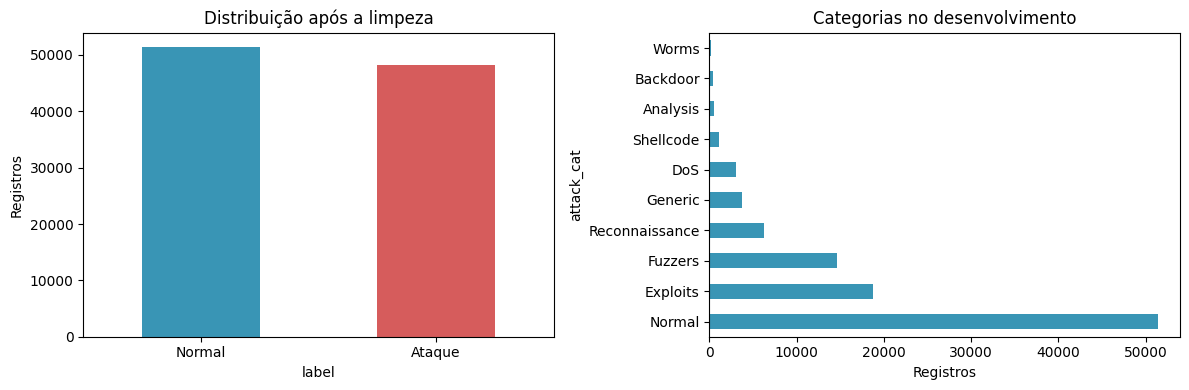

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
desenvolvimento.label.value_counts().sort_index().rename(index={0: 'Normal', 1: 'Ataque'}).plot.bar(
    ax=axes[0], color=['#3995b5', '#d65c5c'], rot=0, title='Distribuição após a limpeza')
desenvolvimento.attack_cat.fillna('Sem categoria').value_counts().plot.barh(
    ax=axes[1], color='#3995b5', title='Categorias no desenvolvimento')
axes[0].set_ylabel('Registros'); axes[1].set_xlabel('Registros')
plt.tight_layout(); plt.show()

**4. Preparar treino, validação e teste**

Reservar 20% do desenvolvimento para validação, a mesma amostra e o mesmo pré-processamento nos dois modelos. Aplicar **log1p** aos números não negativos, imputar pela mediana, padronizar e codificar categorias.

In [4]:
treino, validacao = train_test_split(
    desenvolvimento, test_size=0.2, stratify=desenvolvimento.label, random_state=SEMENTE)
if LIMITE_TREINO is not None and len(treino) > LIMITE_TREINO:
    treino, _ = train_test_split(treino, train_size=LIMITE_TREINO,
                                stratify=treino.label, random_state=SEMENTE)

assert not chaves(treino).isin(chaves(validacao)).any()
assert not chaves(treino).isin(chave_teste).any()
assert not chaves(validacao).isin(chave_teste).any()
assert set(treino.label) == set(validacao.label) == {0, 1}

preprocessador = ColumnTransformer([
    ('numeros', Pipeline([
        ('mediana', SimpleImputer(strategy='median', keep_empty_features=True)),
        ('log', FunctionTransformer(np.log1p, feature_names_out='one-to-one')),
        ('escala', StandardScaler())]), numericas),
    ('categorias', OneHotEncoder(handle_unknown='ignore', sparse_output=False,
                                dtype=np.float32), categoricas)
])
X_treino = preprocessador.fit_transform(treino[atributos]).astype(np.float32)
X_validacao = preprocessador.transform(validacao[atributos]).astype(np.float32)
y_treino = treino.label.to_numpy()
y_validacao = validacao.label.to_numpy()
assert np.isfinite(X_treino).all() and np.isfinite(X_validacao).all()
display(pd.DataFrame({'Partição': ['Treino', 'Validação', 'Teste reservado'],
                      'Registros': [len(treino), len(validacao), len(teste)]}))
print('Entradas após codificação:', X_treino.shape[1])

,Partição,Registros
0,Treino,60000
1,Validação,19922
2,Teste reservado,82332


Entradas após codificação: 194


**5. Treinar o modelo de ML**

Comparar o Random Forest com uma referência que sempre prevê a classe mais frequente. O tempo medido inclui somente o treinamento, na máquina utilizada.

In [5]:
modelos = {
    'Referência': DummyClassifier(strategy='most_frequent'),
    'Random Forest': RandomForestClassifier(n_estimators=100, max_depth=20,
                                           min_samples_leaf=2, n_jobs=-1,
                                           random_state=SEMENTE)
}
tempos = {}
for nome, modelo in modelos.items():
    inicio = time.perf_counter()
    modelo.fit(X_treino, y_treino)
    tempos[nome] = time.perf_counter() - inicio
    print(f'{nome}: {tempos[nome]:.1f} segundos')

Referência: 0.0 segundos
Random Forest: 16.3 segundos


**6. Treinar o modelo de Deep Learning**

Rede neural densa com 128, 64 e 32 neurônios nas três camadas ocultas, ativação ReLU e otimizador Adam. Usar MLPClassifier do scikit-learn: a arquitetura com múltiplas camadas ocultas implementa o modelo profundo, sem dependência de TensorFlow.


In [6]:
rede = MLPClassifier(hidden_layer_sizes=(128, 64, 32), activation='relu',
                     solver='adam', batch_size=256, learning_rate_init=0.001,
                     alpha=0.0001, random_state=SEMENTE, shuffle=True)
historico = {'treino': [], 'validacao': []}
melhor_perda = np.inf
sem_melhora = 0
inicio = time.perf_counter()
with threadpool_limits(limits=2):
    for epoca in range(EPOCAS):
        rede.partial_fit(X_treino, y_treino, classes=np.array([0, 1]))
        perda_val = log_loss(y_validacao, rede.predict_proba(X_validacao), labels=[0, 1])
        historico['treino'].append(float(rede.loss_))
        historico['validacao'].append(float(perda_val))
        print(f'Época {epoca + 1}: perda de validação = {perda_val:.4f}')
        if perda_val < melhor_perda - 0.0001:
            melhor_perda = perda_val
            melhor_rede = copy.deepcopy(rede)
            melhor_epoca = epoca + 1
            sem_melhora = 0
        else:
            sem_melhora += 1
        if sem_melhora >= 3:
            break
tempos['Rede profunda'] = time.perf_counter() - inicio
modelos['Rede profunda'] = melhor_rede
print(f'Melhores pesos: época {melhor_epoca}; treinamento: {tempos["Rede profunda"]:.1f} s')

Época 1: perda de validação = 0.1863
Época 2: perda de validação = 0.1795
Época 3: perda de validação = 0.1754
Época 4: perda de validação = 0.1722
Época 5: perda de validação = 0.1703
Época 6: perda de validação = 0.1693
Época 7: perda de validação = 0.1678
Época 8: perda de validação = 0.1680
Época 9: perda de validação = 0.1668
Época 10: perda de validação = 0.1663
Época 11: perda de validação = 0.1655
Época 12: perda de validação = 0.1645
Época 13: perda de validação = 0.1634
Época 14: perda de validação = 0.1636
Época 15: perda de validação = 0.1631
Época 16: perda de validação = 0.1620
Época 17: perda de validação = 0.1616
Época 18: perda de validação = 0.1616
Época 19: perda de validação = 0.1617
Época 20: perda de validação = 0.1619
Melhores pesos: época 17; treinamento: 101.5 s


**7. Comparar os resultados**

Escolher entre ML e DL pelo maior F1 de validação, com limiar fixo de 0,5. Em empate, usar o menor tempo de treino. Só depois avaliar o teste.
**Precisão:** proporção de alertas corretos.
**Recall:** proporção de ataques detectados.
**F1:** equilíbrio entre ambos. FPR: proporção de tráfego normal sinalizado como ataque. A acurácia complementa a análise. O teste serve para avaliação final, sem ajustar modelos ou limiar.

In [7]:
def pontuacao(modelo, X):
    with threadpool_limits(limits=2):
        return modelo.predict_proba(X)[:, list(modelo.classes_).index(1)]

def metricas(nome, y, score):
    previsto = (score >= LIMIAR).astype(int)
    tn, fp, fn, tp = confusion_matrix(y, previsto, labels=[0, 1]).ravel()
    return {'Modelo': nome, 'Precisão': precision_score(y, previsto, zero_division=0),
            'Recall': recall_score(y, previsto, zero_division=0),
            'F1': f1_score(y, previsto, zero_division=0),
            'Acurácia': accuracy_score(y, previsto), 'FPR': fp / (fp + tn),
            'Treino (s)': tempos[nome]}

resultado_validacao = pd.DataFrame([
    metricas(n, y_validacao, pontuacao(m, X_validacao)) for n, m in modelos.items()
]).set_index('Modelo')
candidatos = resultado_validacao.loc[['Random Forest', 'Rede profunda']]
escolhido = candidatos.sort_values(['F1', 'Treino (s)'], ascending=[False, True]).index[0]
print('Escolha pela validação:', escolhido)
display(resultado_validacao.round(4))

X_teste = preprocessador.transform(teste[atributos]).astype(np.float32)
y_teste = teste.label.to_numpy()
assert np.isfinite(X_teste).all() and set(y_teste) == {0, 1}
scores_teste = {n: pontuacao(m, X_teste) for n, m in modelos.items()}
resultado_teste = pd.DataFrame([
    metricas(n, y_teste, s) for n, s in scores_teste.items()
]).set_index('Modelo')
print('Avaliação final no teste reservado:')
display(resultado_teste.round(4))

Escolha pela validação: Random Forest


,Precisão,Recall,F1,Acurácia,FPR,Treino (s)
Modelo,,,,,,
Referência,0.0000,0.0000,0.0000,0.5157,0.0000,0.0069
Random Forest,0.9014,0.9593,0.9295,0.9295,0.0985,16.3435
Rede profunda,0.9011,0.9408,0.9205,0.9213,0.0970,101.4664


Avaliação final no teste reservado:


,Precisão,Recall,F1,Acurácia,FPR,Treino (s)
Modelo,,,,,,
Referência,0.0000,0.0000,0.0000,0.4494,0.0000,0.0069
Random Forest,0.8062,0.9895,0.8885,0.8632,0.2915,16.3435
Rede profunda,0.8133,0.9832,0.8903,0.8665,0.2765,101.4664


**8. Visualizar o desempenho**

Comparar F1 e recall, matrizes de confusão e evolução da perda da rede.
**Falsos negativos** são ataques não detectados; e
**falsos positivos** aumentam o trabalho de investigação.

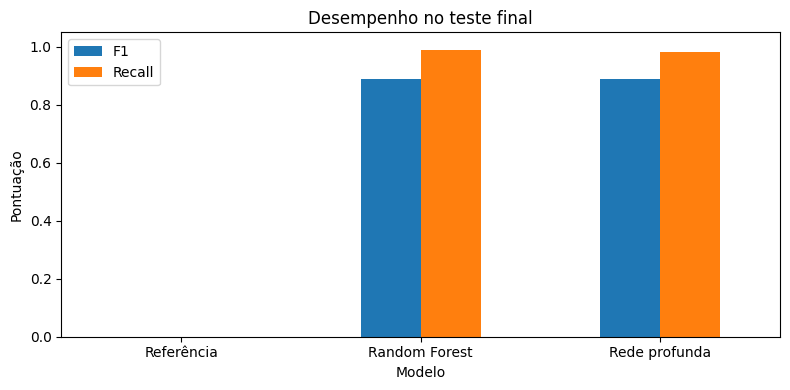

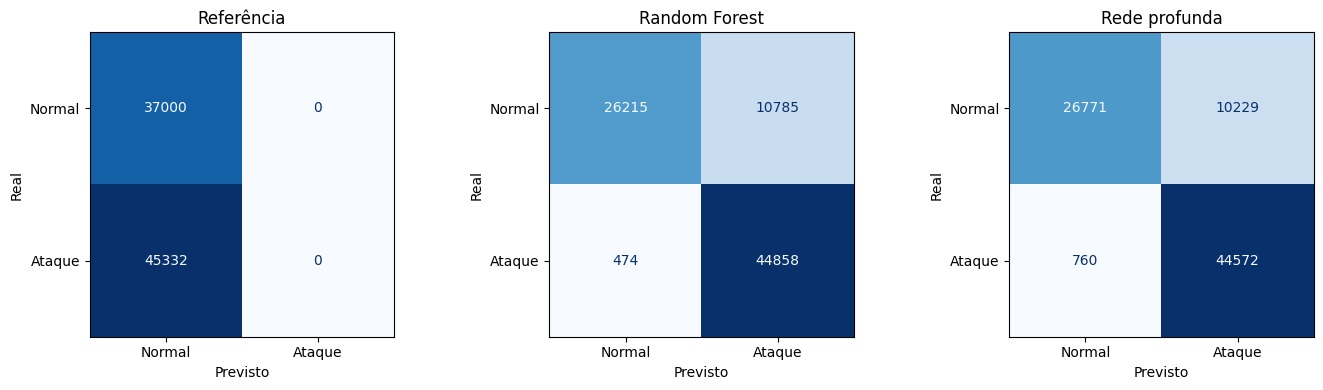

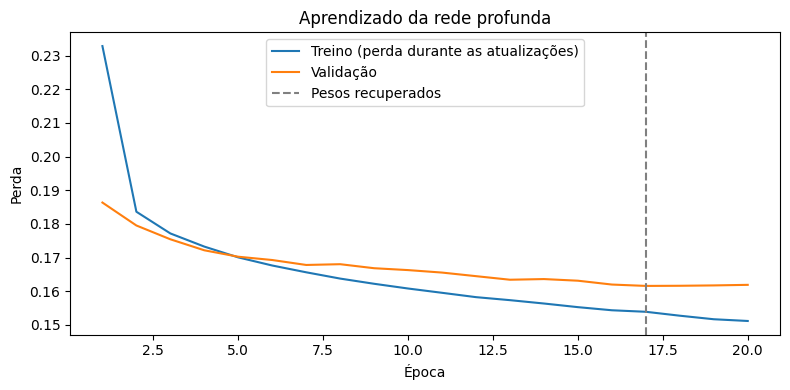

In [8]:
resultado_teste[['F1', 'Recall']].plot.bar(rot=0, ylim=(0, 1.05),
                                        title='Desempenho no teste final')
plt.ylabel('Pontuação'); plt.tight_layout(); plt.show()
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (nome, score) in zip(axes, scores_teste.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_teste, score >= LIMIAR, labels=[0, 1], display_labels=['Normal', 'Ataque'],
        ax=ax, colorbar=False, values_format='d', cmap='Blues')
    ax.set_title(nome); ax.set_xlabel('Previsto'); ax.set_ylabel('Real')
plt.tight_layout(); plt.show()
epocas = np.arange(1, len(historico['treino']) + 1)
plt.plot(epocas, historico['treino'], label='Treino (perda durante as atualizações)')
plt.plot(epocas, historico['validacao'], label='Validação')
plt.axvline(melhor_epoca, linestyle='--', color='gray', label='Pesos recuperados')
plt.xlabel('Época'); plt.ylabel('Perda'); plt.title('Aprendizado da rede profunda')
plt.legend(); plt.tight_layout(); plt.show()

**9. Demonstrar alertas e planejar o piloto**

Exibir os primeiros registros do teste com a decisão do modelo escolhido. O score é uma saída do modelo, não uma probabilidade calibrada de risco.
Para o piloto Multi-Cloud: coletar atributos equivalentes; validar com tráfego local rotulado; ajustar o limiar em validação conforme os custos de alarmes e ataques perdidos; integrar alertas ao monitoramento; medir falsos positivos, recall e tempo de resposta. Neste MVP, cada alerta recomenda investigação humana.

In [9]:
alertas = teste[['proto', 'service', 'state']].head(10).copy()
score = scores_teste[escolhido][:len(alertas)]
alertas['Score do modelo'] = np.round(score, 4)
alertas['Previsão'] = np.where(score >= LIMIAR, 'Ataque', 'Normal')
alertas['Rótulo real'] = np.where(y_teste[:len(alertas)] == 1, 'Ataque', 'Normal')
alertas['Ação sugerida'] = np.where(score >= LIMIAR, 'Investigar evento', 'Monitorar')
display(alertas)

,proto,service,state,Score do modelo,Previsão,Rótulo real,Ação sugerida
0,udp,-,int,0.8447,Ataque,Normal,Investigar evento
1,udp,-,int,0.8453,Ataque,Normal,Investigar evento
2,udp,-,int,0.8274,Ataque,Normal,Investigar evento
3,udp,-,int,0.7508,Ataque,Normal,Investigar evento
4,udp,-,int,0.7238,Ataque,Normal,Investigar evento
5,udp,-,int,0.7894,Ataque,Normal,Investigar evento
6,udp,-,int,0.7673,Ataque,Normal,Investigar evento
7,udp,-,int,0.7994,Ataque,Normal,Investigar evento
8,arp,-,int,0.0086,Normal,Normal,Monitorar
9,arp,-,int,0.0086,Normal,Normal,Monitorar


**10. Conclusão**

A escolha por F1 de validação é um critério acadêmico inicial, onde a aprovação operacional depende também do custo dos erros e dos requisitos da empresa.
**Limitações:** dados históricos de laboratório, uma única divisão de validação, repetições mantidas no teste, treino reduzido e ausência de medição de infraestrutura em produção.

O tempo de treino é uma medida computacional local; ele não estima orçamento nem prazo de implantação. ML e DL são comparados sem presumir que a rede será superior.

In [10]:
r = resultado_teste.loc[escolhido]
base = resultado_teste.loc['Referência', 'F1']
print(f"O modelo escolhido pela validação foi {escolhido}.")
print(f"No teste, apresentou F1 de {r['F1']:.1%}, precisão de {r['Precisão']:.1%}, "
      f"recall de {r['Recall']:.1%} e taxa de falsos positivos de {r['FPR']:.1%}.")
print(f"A taxa de falsos positivos equivale a cerca de {100 * r['FPR']:.0f} alertas por 100 registros normais.")
print(f"Seu treinamento levou {r['Treino (s)']:.1f} segundos neste ambiente.")
if r['F1'] > base:
    print('O modelo superou a referência em F1 no teste, demonstrando aprendizado útil nesta base.')
else:
    print('O modelo não superou a referência em F1 no teste; é necessário revisar a abordagem.')
print('O MVP demonstra classificação e geração de alertas para apoiar a segurança da nova unidade. '
      'A implantação deve avançar para um piloto monitorado com dados da empresa, '
      'critérios de aceitação e análise de custo dos erros antes da aprovação operacional.')

O modelo escolhido pela validação foi Random Forest.
No teste, apresentou F1 de 88.8%, precisão de 80.6%, recall de 99.0% e taxa de falsos positivos de 29.1%.
A taxa de falsos positivos equivale a cerca de 29 alertas por 100 registros normais.
Seu treinamento levou 16.3 segundos neste ambiente.
O modelo superou a referência em F1 no teste, demonstrando aprendizado útil nesta base.
O MVP demonstra classificação e geração de alertas para apoiar a segurança da nova unidade. A implantação deve avançar para um piloto monitorado com dados da empresa, critérios de aceitação e análise de custo dos erros antes da aprovação operacional.
